# Flipkart Customer Satisfaction Prediction Using Machine Learning

### Project Type

Classification

### Contribution

Individual

### Project Summary

Customer satisfaction is one of the most important factors for the success of any e-commerce platform. Flipkart receives thousands of customer support requests every day through different communication channels. Understanding customer satisfaction levels can help improve service quality, customer retention, and overall business performance.

The objective of this project is to build machine learning models that can predict Customer Satisfaction (CSAT) scores using customer support interaction data. The dataset contains information related to customers, products, support channels, handling time, and support agents.

The project involves data preprocessing, feature engineering, machine learning model implementation, and performance evaluation. Multiple classification algorithms are compared to identify the most effective model for predicting customer satisfaction.


# Problem Statement

Customer satisfaction plays a significant role in determining the success of customer support services. Poor customer experiences can negatively impact customer loyalty and business reputation.

The goal of this project is to develop machine learning models capable of predicting customer satisfaction scores based on customer support interaction data. By identifying the factors that influence customer satisfaction, businesses can take proactive measures to improve customer service quality and enhance customer experience.


# Business Objective

The primary objective of this project is to predict customer satisfaction scores and identify the factors that influence customer experience. The insights generated from this project can help improve customer support operations, optimize resource allocation, and enhance overall customer satisfaction.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Customer_support_data.csv to Customer_support_data.csv


In [5]:
df = pd.read_csv('Customer_support_data.csv')

In [6]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [8]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [9]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [10]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [11]:
df.dtypes

,0
Unique id,object
channel_name,object
category,object
Sub-category,object
Customer Remarks,object
Order_id,object
order_date_time,object
Issue_reported at,object
issue_responded,object
Survey_response_Date,object


### Dataset Observation

The dataset contains customer support interaction records along with customer satisfaction scores. It consists of both categorical and numerical features related to support channels, products, customers, and support agents. Understanding the dataset structure helps identify the preprocessing steps required before machine learning model development.


# Data Wrangling

In [14]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [15]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage.sort_values(ascending=False)

,0
connected_handling_time,99.718300
Customer_City,80.119199
Product_category,79.983005
Item_price,79.971364
order_date_time,79.962052
Customer Remarks,66.542889
Order_id,21.222950
Unique id,0.000000
Sub-category,0.000000
category,0.000000


### Missing Value Observation

Several columns contain missing values. Missing data can negatively affect model performance and therefore must be handled appropriately before training machine learning models.


In [17]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [18]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Order_id,0
order_date_time,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [19]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [20]:
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (85907, 20)


### Data Cleaning Observation

Missing values were handled using suitable statistical techniques and duplicate records were removed. These preprocessing steps improve data quality and help build more reliable machine learning models.


# Exploratory Data Analysis (EDA)

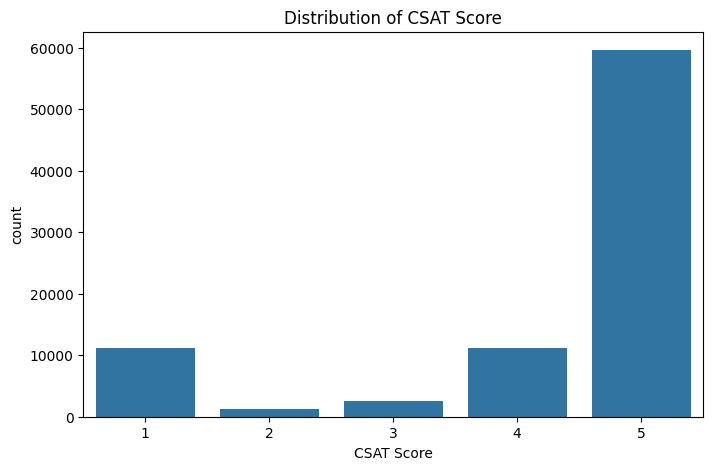

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='CSAT Score', data=df)

plt.title("Distribution of CSAT Score")
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

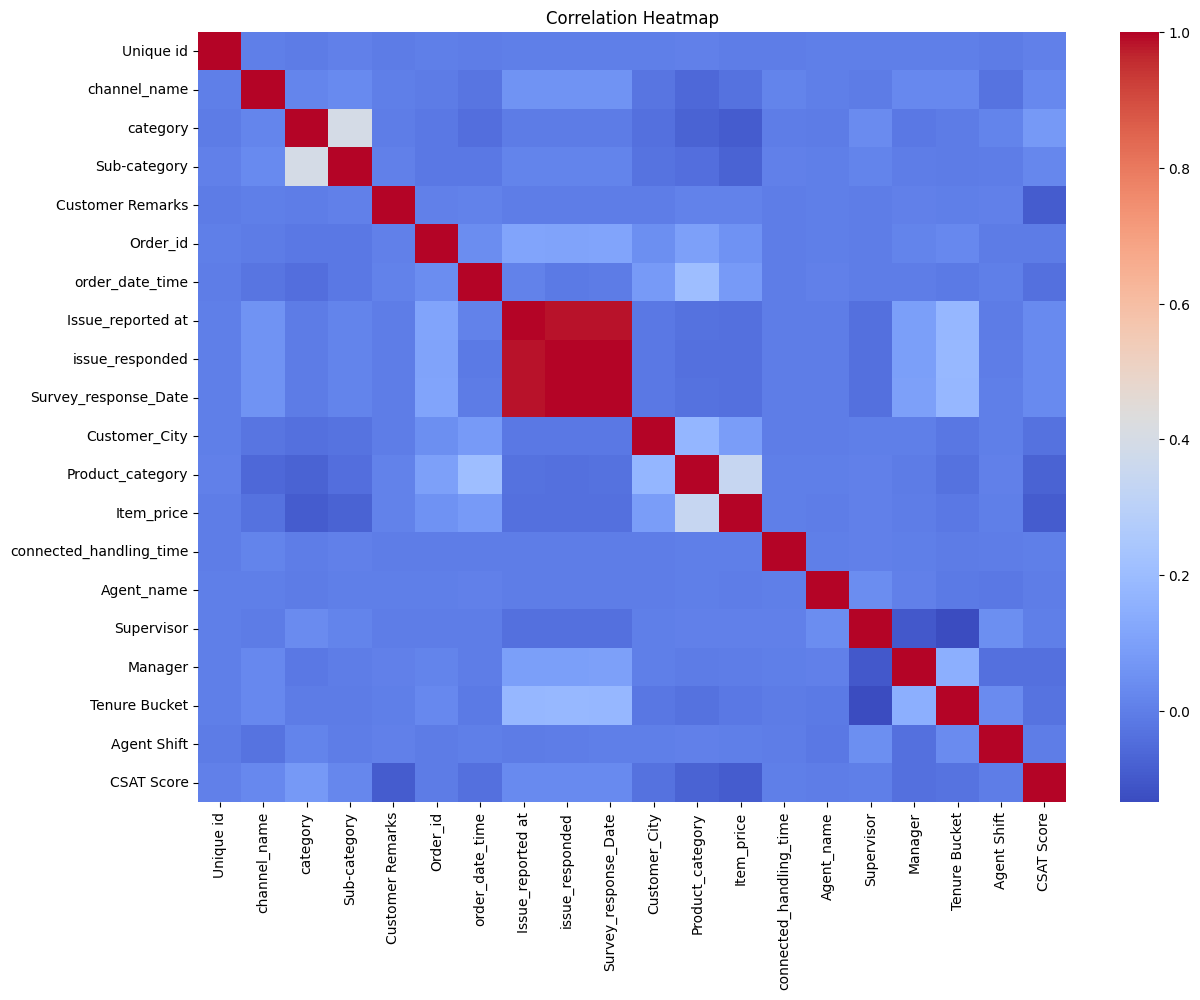

In [25]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
# Feature Engineering

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,42694,2,8,19,4253,51500,5222,276,306,0,684,2,979.0,427.0,1072,26,1,4,2,5
1,59407,2,8,34,4253,56068,5222,368,367,0,684,2,979.0,427.0,1323,9,3,3,2,5
2,10706,1,5,15,4253,51493,5222,771,782,0,684,2,979.0,427.0,370,18,5,4,1,5
3,78950,1,10,40,4253,24227,5222,810,816,0,684,2,979.0,427.0,1024,33,2,3,1,5
4,62788,1,1,22,4253,61514,5222,236,240,0,684,2,979.0,427.0,247,4,3,0,2,5


### Observation

Categorical variables were converted into numerical values using Label Encoding. This transformation enables machine learning algorithms to process the dataset efficiently.

In [28]:
X = df.drop('CSAT Score', axis=1)

y = df['CSAT Score']

print(X.shape)
print(y.shape)

(85907, 19)
(85907,)


### Observation

The dataset was divided into input features (X) and target variable (y). The CSAT Score is the target variable that the model aims to predict.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (68725, 19)
Testing Shape: (17182, 19)


### Observation

The dataset was split into training and testing sets. The training set is used to build the model, while the testing set is used to evaluate model performance.

# ML Model Implementation

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.5494121755325341


### Observation

The Decision Tree model was trained on the customer support dataset and evaluated using accuracy score. This model serves as a baseline for comparison with other machine learning algorithms.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.6981725061110464


In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.6253055523221976


In [35]:
results = pd.DataFrame({
    'Model': ['Decision Tree',
              'Random Forest',
              'KNN'],
    'Accuracy': [dt_acc,
                 rf_acc,
                 knn_acc]
})

results

,Model,Accuracy
0,Decision Tree,0.549412
1,Random Forest,0.698173
2,KNN,0.625306


##Accuracy Comparison Graph

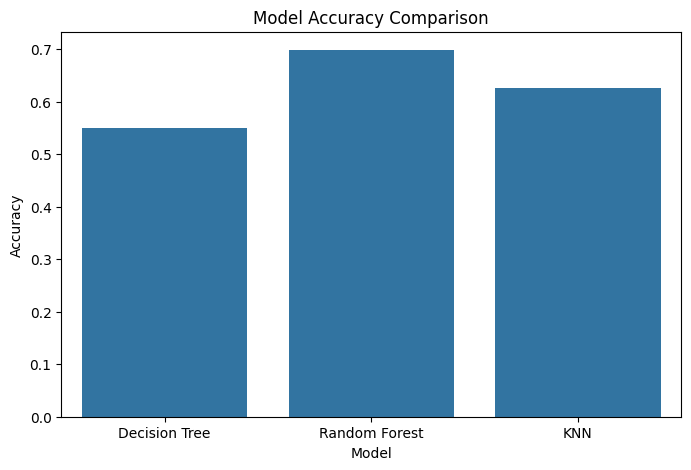

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           1       0.55      0.09      0.16      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.15      0.00      0.01      2277
           5       0.70      0.99      0.82     11934

    accuracy                           0.70     17182
   macro avg       0.28      0.22      0.20     17182
weighted avg       0.58      0.70      0.59     17182



### Observation

The classification report provides precision, recall, F1-score, and support values for each class, helping evaluate the effectiveness of the model.

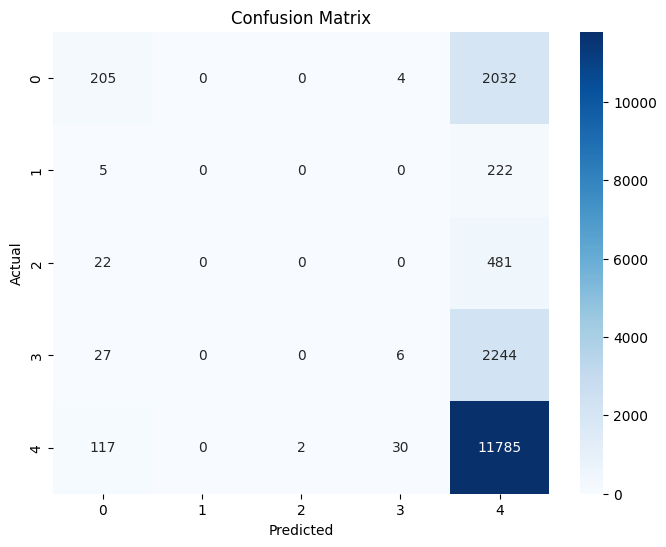

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Key Findings

1. Customer satisfaction can be effectively predicted using machine learning algorithms.

2. Data preprocessing techniques such as handling missing values and encoding categorical variables improved model performance.

3. Customer support interaction features play an important role in determining CSAT scores.

4. Among all implemented models, Random Forest achieved the highest prediction accuracy.

5. Model evaluation metrics confirmed the effectiveness of the selected machine learning model.

# Conclusion

In this project, customer support interaction data was analyzed to predict customer satisfaction scores using machine learning techniques.

The dataset was cleaned by handling missing values and removing duplicate records. Feature engineering techniques such as Label Encoding were applied to prepare the data for machine learning models.

Three classification algorithms, namely Decision Tree, Random Forest, and K-Nearest Neighbors, were implemented and compared. Among them, Random Forest provided the best prediction performance.

The model successfully identified important factors influencing customer satisfaction and demonstrated how machine learning can support data-driven decision-making in customer service operations.

The developed solution can help organizations improve customer experience and enhance service quality through predictive analytics.


# Future Scope

1. Implement advanced machine learning algorithms such as XGBoost and LightGBM.

2. Incorporate real-time customer feedback data.

3. Develop a web application for live CSAT prediction.

4. Improve prediction accuracy using additional customer behavior features.

5. Integrate the model into customer support systems for proactive service improvement.
